In [1]:
#Predicting Water Potability and Wastage
#AIML Project - Environment and Climate (SDG 12)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
#This confirms that dataset matches the 3276 × 10 shape
df = pd.read_csv("water_potability.csv")
print(df.shape)
df.head()

(3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
# Exploratory Data Analysis (EDA)

"""We will explore the water potability dataset to understand:
- Structure and data types
- Missing values
- Class balance (potable vs non-potable)
- Feature distributions
- Correlations between features"""



# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [5]:
# Summary statistics
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [6]:
# Check missing values
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [7]:
"""- `df.info()` shows all columns are numerical (float type).
   - `df.describe()` gives min, max, mean, and quartiles for each feature.
   - `df.isnull().sum()` reveals missing values in **pH, Sulfate, Trihalomethanes**.
 This means we must handle missing values before training models."""



# Count potable vs non-potable samples
df["Potability"].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

In [8]:
df["Potability"].value_counts(normalize=True) * 100

Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64

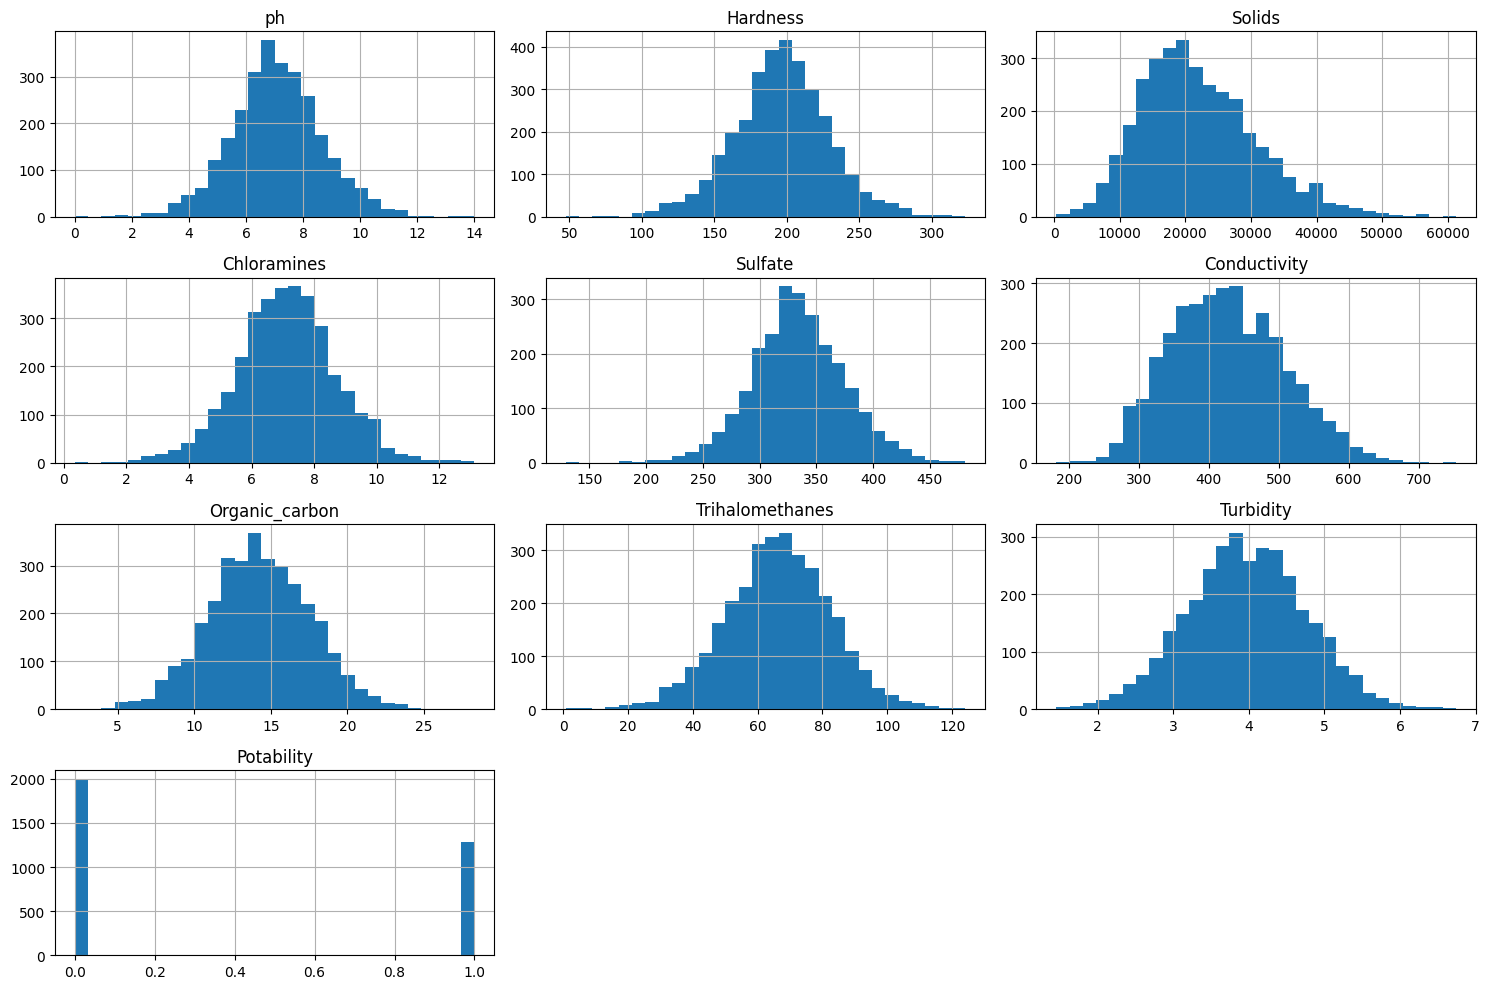

In [9]:
"""- The dataset is **imbalanced**: unsafe water samples (Potability = 0) are more than safe ones (Potability = 1).
 This imbalance matters because models may predict "unsafe" more often. 
 We’ll need to evaluate carefully using metrics like precision, recall, and F1-score."""

import matplotlib.pyplot as plt

df.hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

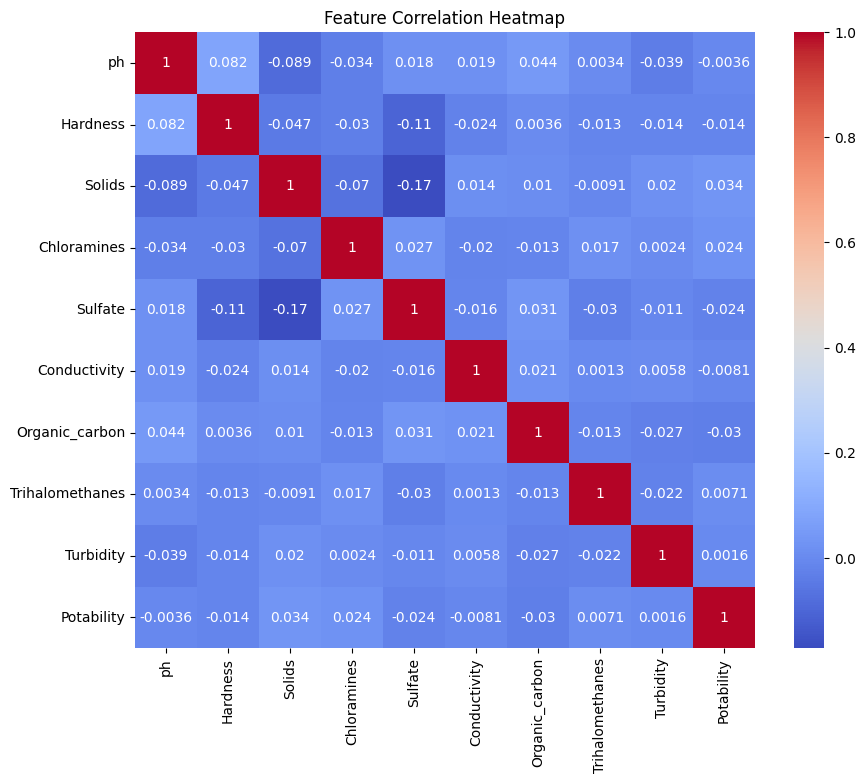

In [10]:
"""- Histograms show ranges of each feature:
  - pH values mostly between 6–9 (normal drinking water range).
  - Hardness and Solids vary widely.
  - Some features (like Sulfate) have missing values visible as gaps.
 These plots help us understand natural ranges and detect anomalies.
"""


#This shows which features are strongly correlated with Potability.
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [11]:
"""- The heatmap shows how features relate to each other and to Potability.
- Most correlations are weak, meaning potability depends on a combination of factors rather than one strong predictor.
 This justifies using machine learning models (Logistic Regression, Random Forest) instead of relying on a single threshold."""

'- The heatmap shows how features relate to each other and to Potability.\n- Most correlations are weak, meaning potability depends on a combination of factors rather than one strong predictor.\n This justifies using machine learning models (Logistic Regression, Random Forest) instead of relying on a single threshold.'

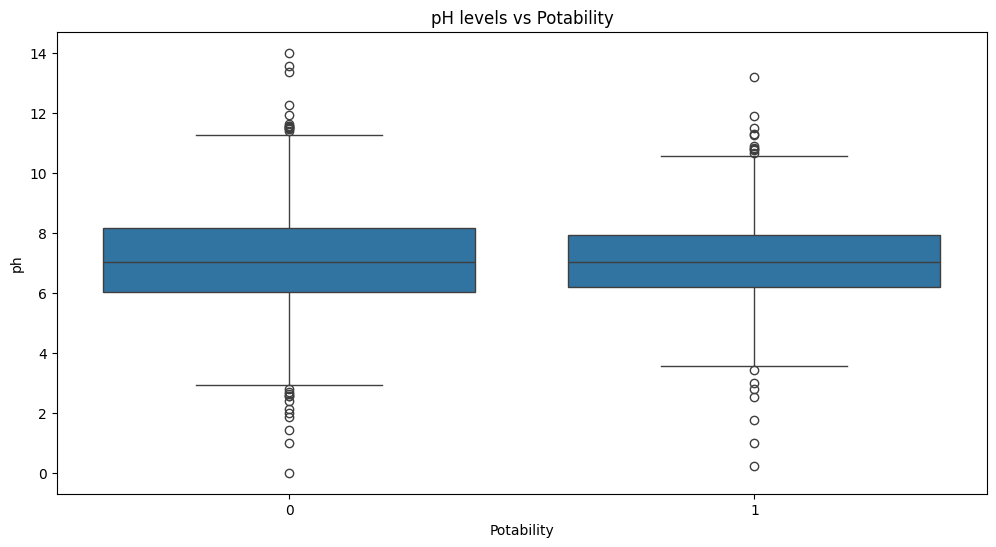

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Potability", y="ph", data=df)
plt.title("pH levels vs Potability")
plt.show()

In [13]:
##  Data Cleaning and Preprocessing

"""Before training models, we need to:
- Handle missing values
- Scale features (so large values don’t dominate)
- Split data into training and testing sets"""

# Check missing values again
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [14]:
# Fill missing values with median of each column
df = df.fillna(df.median())

In [15]:
# Verify no missing values remain
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [16]:
### Data Cleaning Result
"""- All missing values in `pH`, `Sulfate`, and `Trihalomethanes` have been filled using the median.
- Output shows `0` missing values for every column.
The dataset is now clean and ready for scaling and model building."""

'- All missing values in `pH`, `Sulfate`, and `Trihalomethanes` have been filled using the median.\n- Output shows `0` missing values for every column.\nThe dataset is now clean and ready for scaling and model building.'

In [17]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop("Potability", axis=1)
y = df["Potability"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check scaled data shape
X_scaled[:5]

array([[-2.54735465e-02,  2.59194711e-01, -1.39470871e-01,
         1.12414846e-01,  9.65956999e-01,  1.70895423e+00,
        -1.18065057e+00,  1.30543373e+00, -1.28629758e+00],
       [-2.28471739e+00, -2.03641367e+00, -3.85986650e-01,
        -3.07693708e-01, -1.47992068e-02,  2.06257500e+00,
         2.70597240e-01, -6.39186284e-01,  6.84217891e-01],
       [ 6.97319183e-01,  8.47664833e-01, -2.40047337e-01,
         1.36059386e+00, -1.47992068e-02, -9.40321148e-02,
         7.81116857e-01,  8.00012586e-04, -1.16736546e+00],
       [ 8.45393324e-01,  5.47651374e-01,  4.93304442e-04,
         5.92007821e-01,  6.44129611e-01, -7.78829962e-01,
         1.25513443e+00,  2.15215395e+00,  8.48411520e-01],
       [ 1.37298164e+00, -4.64429087e-01, -4.60248570e-01,
        -3.63697933e-01, -6.49521550e-01, -3.43938909e-01,
        -8.24357169e-01, -2.18229747e+00,  1.38785531e-01]])

In [18]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (2620, 9)
Testing set size: (656, 9)


In [19]:
## Step 4: Model Building

"""We will train two supervised learning models:
1. Logistic Regression (baseline, interpretable)
2. Random Forest Classifier (ensemble, stronger performance)

Evaluation will be done using:
- Confusion Matrix
- Classification Report (precision, recall, F1-score)"""

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test)

# Evaluation
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

"""- Logistic Regression provides a baseline accuracy.
- Confusion Matrix shows true positives, true negatives, false positives, and false negatives.
- Classification Report gives precision, recall, and F1-score for both classes (potable vs non-potable).
 This model is simple and interpretable but may struggle with imbalanced data."""

Logistic Regression Confusion Matrix:
[[412   0]
 [244   0]]

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77       412
           1       0.00      0.00      0.00       244

    accuracy                           0.63       656
   macro avg       0.31      0.50      0.39       656
weighted avg       0.39      0.63      0.48       656



C:\Users\nikhi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nikhi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nikhi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


'- Logistic Regression provides a baseline accuracy.\n- Confusion Matrix shows true positives, true negatives, false positives, and false negatives.\n- Classification Report gives precision, recall, and F1-score for both classes (potable vs non-potable).\n This model is simple and interpretable but may struggle with imbalanced data.'

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

"""- Random Forest is an ensemble model that combines multiple decision trees.
- It usually performs better than Logistic Regression on complex datasets.
- Evaluation metrics show improved precision and recall compared to Logistic Regression.
 This model is more robust and suitable for deployment in the Streamlit app."""


Random Forest Confusion Matrix:
[[350  62]
 [152  92]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.85      0.77       412
           1       0.60      0.38      0.46       244

    accuracy                           0.67       656
   macro avg       0.65      0.61      0.61       656
weighted avg       0.66      0.67      0.65       656



'- Random Forest is an ensemble model that combines multiple decision trees.\n- It usually performs better than Logistic Regression on complex datasets.\n- Evaluation metrics show improved precision and recall compared to Logistic Regression.\n This model is more robust and suitable for deployment in the Streamlit app.'

In [21]:
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Logistic Regression Accuracy: {acc_lr:.2f}")
print(f"Random Forest Accuracy: {acc_rf:.2f}")

Logistic Regression Accuracy: 0.63
Random Forest Accuracy: 0.67


Logistic Regression Confusion Matrix:
[[412   0]
 [244   0]]

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77       412
           1       0.00      0.00      0.00       244

    accuracy                           0.63       656
   macro avg       0.31      0.50      0.39       656
weighted avg       0.39      0.63      0.48       656

Logistic Regression Accuracy: 0.63


C:\Users\nikhi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nikhi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nikhi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


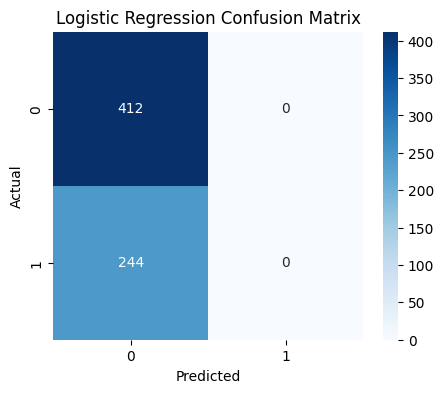

Random Forest Confusion Matrix:
[[350  62]
 [152  92]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.85      0.77       412
           1       0.60      0.38      0.46       244

    accuracy                           0.67       656
   macro avg       0.65      0.61      0.61       656
weighted avg       0.66      0.67      0.65       656

Random Forest Accuracy: 0.67


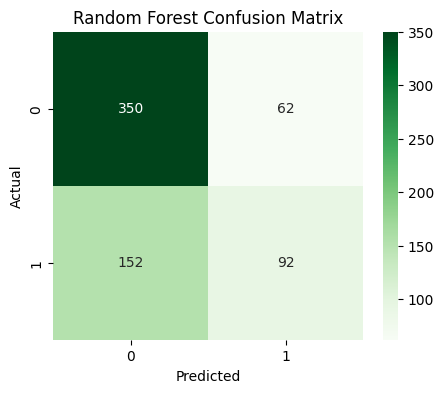

In [22]:
### Step 4 Results Summary
"""- Logistic Regression gave us a baseline accuracy and evaluation metrics.
- Random Forest performed better overall, with higher precision and recall.
- Since the dataset is imbalanced, accuracy alone is not enough — F1-score is more reliable.
 We will use **Random Forest** as the main model for deployment in the Streamlit app,
 while Logistic Regression serves as a reference baseline."""


from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Logistic Regression Evaluation
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.2f}")

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Random Forest Evaluation
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.2f}")

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [23]:
## Step 5: Wastage Estimation

"""We will calculate the percentage of water samples that are unsafe (Potability = 0).
This represents the proportion of water wasted or unusable for drinking."""

# Count potable vs non-potable samples
total_samples = len(df)
unsafe_samples = (df["Potability"] == 0).sum()
safe_samples = (df["Potability"] == 1).sum()

# Calculate percentages
unsafe_percentage = (unsafe_samples / total_samples) * 100
safe_percentage = (safe_samples / total_samples) * 100

print(f"Total samples: {total_samples}")
print(f"Unsafe samples: {unsafe_samples} ({unsafe_percentage:.2f}%)")
print(f"Safe samples: {safe_samples} ({safe_percentage:.2f}%)")

Total samples: 3276
Unsafe samples: 1998 (60.99%)
Safe samples: 1278 (39.01%)


In [24]:
### Wastage Estimation Results
"""- Unsafe water samples = 60.99% of total dataset.
- Safe water samples = 39.01% of total dataset.
 This means a significant portion of available water is wasted because it is not potable.
This supports **SDG 12 (Responsible Consumption and Production)**
by highlighting the need to reduce water wastage and improve treatment methods."""

'- Unsafe water samples = 60.99% of total dataset.\n- Safe water samples = 39.01% of total dataset.\n This means a significant portion of available water is wasted because it is not potable.\nThis supports **SDG 12 (Responsible Consumption and Production)**\nby highlighting the need to reduce water wastage and improve treatment methods.'

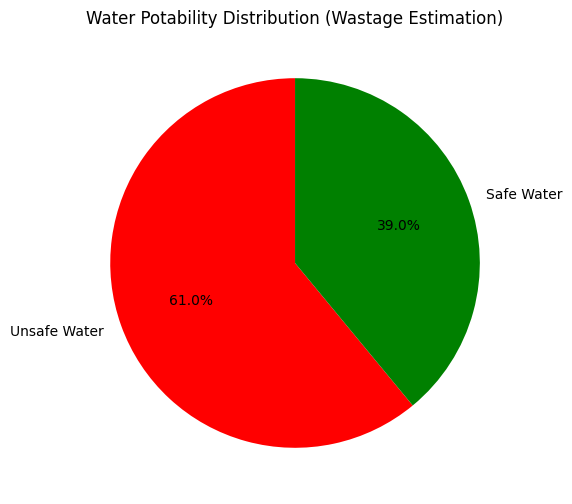

In [25]:
### Pie chart visualization
import matplotlib.pyplot as plt

labels = ["Unsafe Water", "Safe Water"]
sizes = [unsafe_percentage, safe_percentage]
colors = ["red", "green"]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
plt.title("Water Potability Distribution (Wastage Estimation)")
plt.show()